# Validating Linear Regression Assumptions in Retail Analytics

**Objective:** Build a robust Ordinary Least Squares (OLS) regression model to predict weekly sales based on advertising spend. 

In real-world data science, fitting a model is only half the job. To ensure our budget allocation recommendations are reliable, we must rigorously validate the four Gauss-Markov assumptions of linear regression: Linearity, Independence, Normality, and Homoscedasticity. 

This notebook demonstrates an Object-Oriented approach to automating both the statistical and visual validation of these assumptions.

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any

# Set visual style
sns.set_theme(style="whitegrid")

## 1. The Diagnostic Tool: `LinearAssumptionTester`

To make our analysis reproducible and clean, we encapsulate the model fitting, statistical testing, and visualization logic into a single Python class. This highlights clean code practices and modularity.

In [3]:
class LinearAssumptionTester:
    """Class to test OLS Gauss-Markov assumptions."""
    
    def __init__(self, x: pd.Series, y: pd.Series):
        self.x = sm.add_constant(x)
        self.y = y
        self.model = None
        self.predictions = None
        self.residuals = None

    def fit(self):
        """Fit OLS model and extract predictions/residuals."""
        self.model = sm.OLS(self.y, self.x).fit()
        self.predictions = self.model.predict(self.x)
        self.residuals = self.model.resid
        return self.model

    def run_statistical_tests(self) -> Dict[str, Any]:
        """Run formal statistical tests for the assumptions."""
        if self.model is None:
            raise ValueError("Model not fitted. Call .fit() first.")

        results = {}
        # 1. Independence (Durbin-Watson)
        results['Independence (Durbin-Watson)'] = {'Statistic': round(durbin_watson(self.residuals), 3)}
        # 2. Normality (Shapiro-Wilk)
        shapiro_stat, shapiro_p = stats.shapiro(self.residuals)
        results['Normality (Shapiro-Wilk)'] = {'Statistic': round(shapiro_stat, 3), 'p-value': round(shapiro_p, 4)}
        # 3. Homoscedasticity (Breusch-Pagan)
        bp_stat, bp_p, _, _ = sms.het_breuschpagan(self.residuals, self.model.model.exog)
        results['Homoscedasticity (Breusch-Pagan)'] = {'Statistic': round(bp_stat, 3), 'p-value': round(bp_p, 4)}
        # 4. Linearity (Residual Mean Check)
        results['Linearity (Residual Mean)'] = {'Mean': round(np.mean(self.residuals), 5)}

        return results

    def plot_diagnostics(self):
        """Generate 2x2 grid of diagnostic plots."""
        if self.model is None:
            raise ValueError("Model not fitted.")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Linear Regression Assumptions Diagnostics', fontsize=16, weight='bold')

        # Linearity
        sns.residplot(x=self.predictions, y=self.residuals, lowess=True, 
                      scatter_kws={'alpha': 0.6, 'edgecolor': 'k'}, 
                      line_kws={'color': 'red', 'lw': 2}, ax=axes[0, 0])
        axes[0, 0].set_title('Linearity: Residuals vs Fitted', fontsize=12)

        # Normality
        sm.qqplot(self.residuals, line='45', fit=True, ax=axes[0, 1], alpha=0.6)
        axes[0, 1].set_title('Normality: Q-Q Plot', fontsize=12)

        # Homoscedasticity
        standardized_res = self.model.get_influence().resid_studentized_internal
        sns.regplot(x=self.predictions, y=np.sqrt(np.abs(standardized_res)), scatter=True, lowess=True, 
                    scatter_kws={'alpha': 0.6, 'edgecolor': 'k'}, line_kws={'color': 'red', 'lw': 2}, ax=axes[1, 0])
        axes[1, 0].set_title('Homoscedasticity: Scale-Location Plot', fontsize=12)

        # Independence
        axes[1, 1].plot(self.residuals.index, self.residuals, color='teal', marker='o', linestyle='-', alpha=0.6)
        axes[1, 1].axhline(0, color='red', linestyle='--')
        axes[1, 1].set_title('Independence: Residuals vs Order', fontsize=12)

        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()

## 2. Generating Synthetic Retail Data

To test our class, we'll simulate an environment where Advertising Spend directly drives Weekly Sales, adding standard random noise to mimic real-world variance.

In [4]:
# Generate synthetic data
np.random.seed(42)
ad_spend = pd.Series(np.random.uniform(10, 150, 200), name="Ad_Spend")
sales = pd.Series(50 + 3.2 * ad_spend + np.random.normal(0, 25, 200), name="Weekly_Sales")

## 3. Model Fitting & Statistical Validation

We instantiate our analyzer, fit the OLS model, and run rigorous statistical tests to objectively quantify our assumptions rather than relying solely on visual interpretation.

In [6]:
# Initialize, fit, and print coefficients
analyzer = LinearAssumptionTester(x=ad_spend, y=sales)
model_results = analyzer.fit()

print("OLS Model Coefficients")
print(model_results.summary().tables[1])

print("\n DIAGNOSTIC STATISTICAL TEST")
for test_name, metrics in analyzer.run_statistical_tests().items():
    print(f"{test_name.ljust(35)} | {metrics}")

OLS Model Coefficients
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         52.7694      3.668     14.385      0.000      45.535      60.004
Ad_Spend       3.1861      0.042     76.421      0.000       3.104       3.268

 DIAGNOSTIC STATISTICAL TEST
Independence (Durbin-Watson)        | {'Statistic': np.float64(2.131)}
Normality (Shapiro-Wilk)            | {'Statistic': np.float64(0.988), 'p-value': np.float64(0.0862)}
Homoscedasticity (Breusch-Pagan)    | {'Statistic': np.float64(3.556), 'p-value': np.float64(0.0593)}
Linearity (Residual Mean)           | {'Mean': np.float64(-0.0)}


**Statistical Interpretation:**
* **Independence:** A Durbin-Watson score close to 2.0 indicates no severe autocorrelation.
* **Normality:** A Shapiro-Wilk p-value > 0.05 fails to reject the null hypothesis, suggesting errors are normally distributed.
* **Homoscedasticity:** A Breusch-Pagan p-value > 0.05 indicates variance is constant.

## 4. Visual Diagnostics

Finally, we generate a 2x2 grid to visually confirm the statistical results. A picture is worth a thousand data points when presenting to stakeholders.

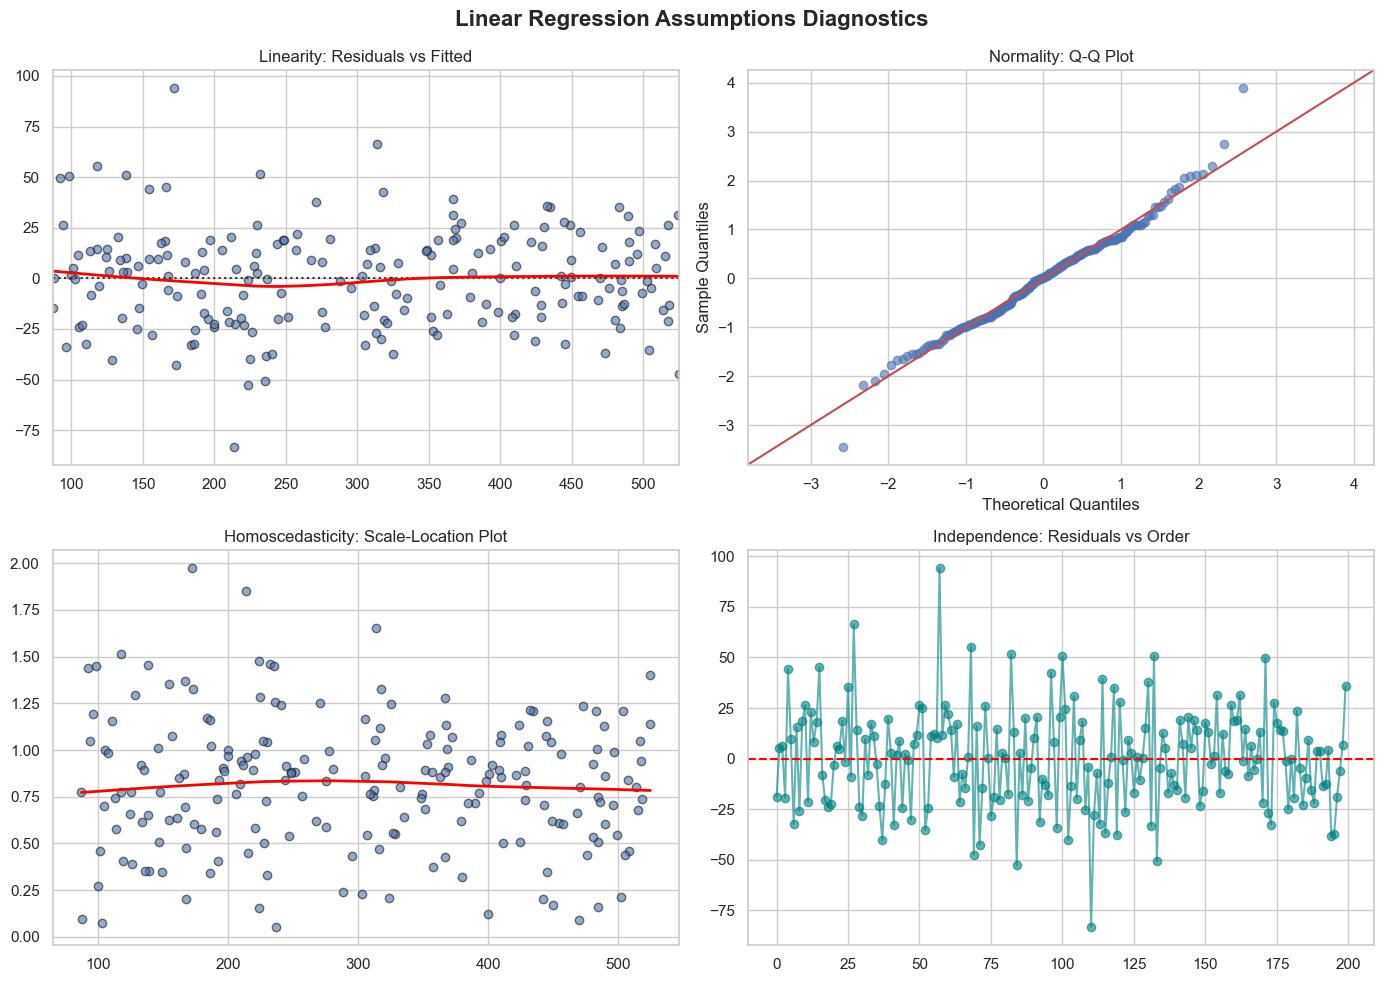

In [7]:
# Generate diagnostic plots
analyzer.plot_diagnostics()

## Conclusion

Both our statistical tests and visual diagnostics confirm that this model satisfies the core assumptions of linear regression. We can confidently present this model to the stakeholders, knowing our coefficient estimates are unbiased and our confidence intervals are reliable for budget allocation decisions.